A notebook to generate plots from the post processed results of an across condition analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
from pathlib import Path
import pickle
import re

from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from janelia_core.stats.regression import r_squared
from janelia_core.visualization.matrix_visualization import colorized_tbl

from probabilistic_model_synthesis.visualization import import_style
import_style()

In [3]:
# %matplotlib notebook

## Parameters go here 

In [4]:
# Top-level directory holding the results
base_dir = r'/groups/ahrens/ahrenslab/Luuk/projects/dpms_manuscript/probabilistic_model_synthesis/results/publication_results/gnldr/quantification'
# base_dir = r'/groups/fitzgerald/fitzgeraldlab/bishoplab/projects/probabilistic_model_synthsis/results/publication_results/gnldr/quantification'

# Name used for all files containing post-processed results
pp_file = r'pp_fit_results.pt'

# Specify the type of models we assess performance for - can be 'sp' or 'ip'
mdl_type = 'ip'

# Specify conditions we test on 
test_conds = ['omr_forward', 'omr_right', 'omr_left']

# Specify folder to save images in 
save_folder = r'/groups/ahrens/ahrenslab/Luuk/projects/dpms_manuscript/probabilistic_model_synthesis/results/publication_results/gnldr/quantification/imgs'



In [5]:
import os

if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

## Load all results

In [6]:
train_conds = [cond.name for cond in Path(base_dir).iterdir() if (cond.is_dir() 
                   and re.match('omr*', str(cond.name)[0:2]) is not None)]
test_subjs = np.sort([int(re.search('.*_(\d+)', subj.name)[1]) 
                      for subj in (Path(base_dir) / train_conds[0]).iterdir() 
                      if re.match('.*subj', str(subj)) is not None])

In [7]:
FIT_TYPES = ['multi_cond', 'single_cond']

In [8]:
rs = dict()
for cond in train_conds:
    rs[cond] = dict()
    for subj in test_subjs:
        rs[cond][subj] = dict()
        for fit_type in FIT_TYPES:
            fit_type_dir = Path(base_dir) / cond / ('subj_' + str(subj)) / fit_type
            fit_type_file = fit_type_dir / pp_file
            
            rs[cond][subj][fit_type] = torch.load(fit_type_file)
            
            # Print some diagonstic information 
            print('Results for subject ' + str(subj) + ', train condition: ' + cond + 
                  ', fit type: ' + fit_type + ' ***')
            print('Best CP Ind: ' + str(rs[cond][subj][fit_type][mdl_type]['early_stopping']['best_cp_ind']))
            
      

/tmp/ipykernel_1718900/1158921110.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rs[cond][subj][fit_type] = torch.load(fit_type_file)


Results for subject 8, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 11, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 11, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_l_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_l_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_l_ns, fit type: multi_cond ***
Best CP Ind: 2
Results for subject 9, train condition: omr_l_ns, fit type: single_cond ***
Best CP Ind: 2
Results for subject 11, train condition: omr_l_ns, fit type: multi_cond ***
Best CP Ind: 1
Re

## Now assess test performance 

In [9]:
subj_elbos = dict()
for subj in test_subjs:
    subj_elbos[subj] = {'multi_cond': pd.DataFrame(np.zeros([3,3]), index=train_conds, columns=test_conds), 
                        'single_cond': pd.DataFrame(np.zeros([3,3]), index=train_conds, columns=test_conds)}

In [10]:
for ts_i, test_cond in enumerate(test_conds):
    print('**** Test Condition: ' + test_cond + ' ****')
    for s_i, subj in enumerate(test_subjs):
        print('Subject: ' + str(subj))
        print('Single ELBO, Multi ELBO, Delta, Training Condition')
        for tr_i, train_cond in enumerate(train_conds):
            single_period_elbo_vls = rs[train_cond][subj]['single_cond'][mdl_type]['period_elbo_vls'][subj]
            multi_period_elbo_vls = rs[train_cond][subj]['multi_cond'][mdl_type]['period_elbo_vls'][subj]
            
            if single_period_elbo_vls[test_cond] is not None:
                single_elbo = single_period_elbo_vls[test_cond]['vl']['elbo'].item()/single_period_elbo_vls[test_cond]['n_smps']
                multi_elbo = multi_period_elbo_vls[test_cond]['vl']['elbo'].item()/multi_period_elbo_vls[test_cond]['n_smps']
                delta_elbo = multi_elbo - single_elbo
                print('{:.2E}'.format(single_elbo) + ', ' + '{:.2E}'.format(multi_elbo) + ', ' + 
                      '{:.2E}'.format(delta_elbo) + ', ' + train_cond)
                
                subj_elbos[subj]['single_cond'][test_cond][train_cond] = single_elbo
                subj_elbos[subj]['multi_cond'][test_cond][train_cond] = multi_elbo

**** Test Condition: omr_forward ****
Subject: 8
Single ELBO, Multi ELBO, Delta, Training Condition
-9.07E+04, -9.08E+04, -1.03E+02, omr_f_ns
-1.22E+05, -1.18E+05, 4.18E+03, omr_l_ns
-1.26E+05, -1.23E+05, 3.11E+03, omr_r_ns
Subject: 9
Single ELBO, Multi ELBO, Delta, Training Condition
-1.03E+05, -1.03E+05, -4.01E+02, omr_f_ns
-1.98E+05, -1.85E+05, 1.33E+04, omr_l_ns
-2.19E+05, -2.03E+05, 1.61E+04, omr_r_ns
Subject: 11
Single ELBO, Multi ELBO, Delta, Training Condition
-1.02E+05, -1.02E+05, 6.96E+02, omr_f_ns
-1.23E+05, -1.19E+05, 3.85E+03, omr_l_ns
-1.18E+05, -1.14E+05, 3.35E+03, omr_r_ns
**** Test Condition: omr_right ****
Subject: 8
Single ELBO, Multi ELBO, Delta, Training Condition
-1.30E+05, -1.28E+05, 2.15E+03, omr_f_ns
-1.51E+05, -1.34E+05, 1.74E+04, omr_l_ns
-8.89E+04, -8.92E+04, -2.80E+02, omr_r_ns
Subject: 9
Single ELBO, Multi ELBO, Delta, Training Condition
-1.22E+05, -1.18E+05, 3.77E+03, omr_f_ns
-1.50E+05, -1.37E+05, 1.36E+04, omr_l_ns
-8.82E+04, -8.85E+04, -2.49E+02, omr_r

In [11]:
for subj in test_subjs:
    subj_elbos[subj]['multi_cond'] = subj_elbos[subj]['multi_cond'].rename(
        columns={'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L'}, 
        index={'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L'})
    
    subj_elbos[subj]['single_cond'] = subj_elbos[subj]['single_cond'].rename(
        columns={'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L'}, 
        index={'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L'})

## Make tables of improvements in Normalized ELBO values when models are synthesized using data of different behaviors across fish

In [12]:
vl_range = 15000

In [13]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name='red_to_green', colors=[(0,  [0.0, 0.0, 1.0, 1.0]),
                                                               (.5, [0.0, 0.0, 0.0, 0.0]),
                                                               (1.0, [1.0, 0.0, 0.0, 1.0])], N=1024)

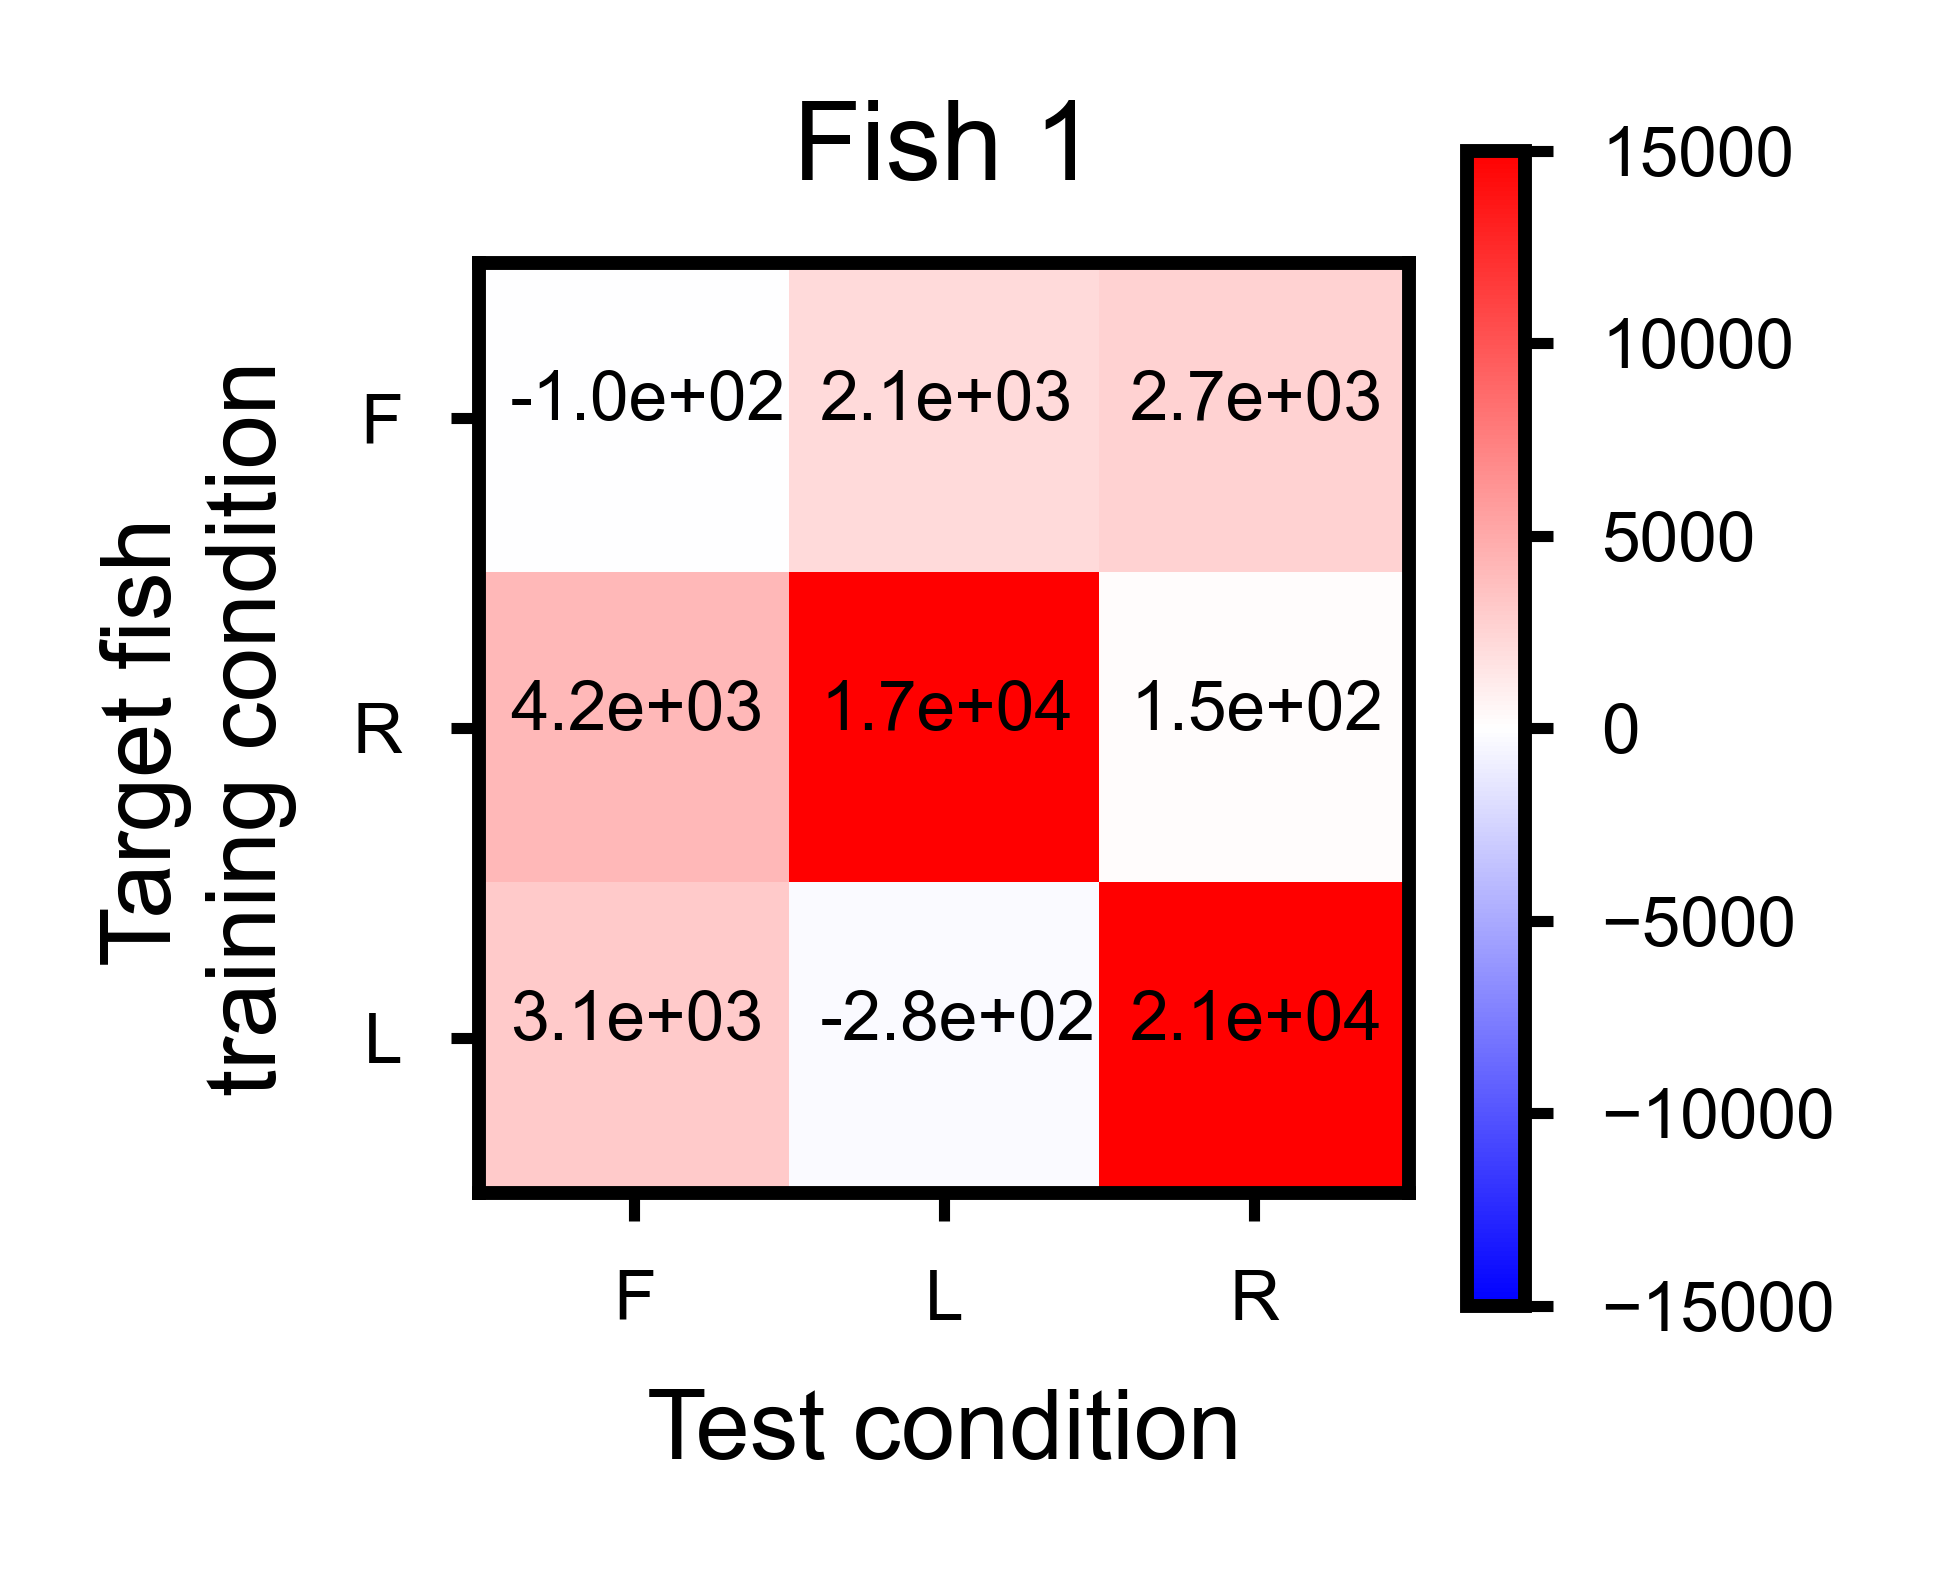

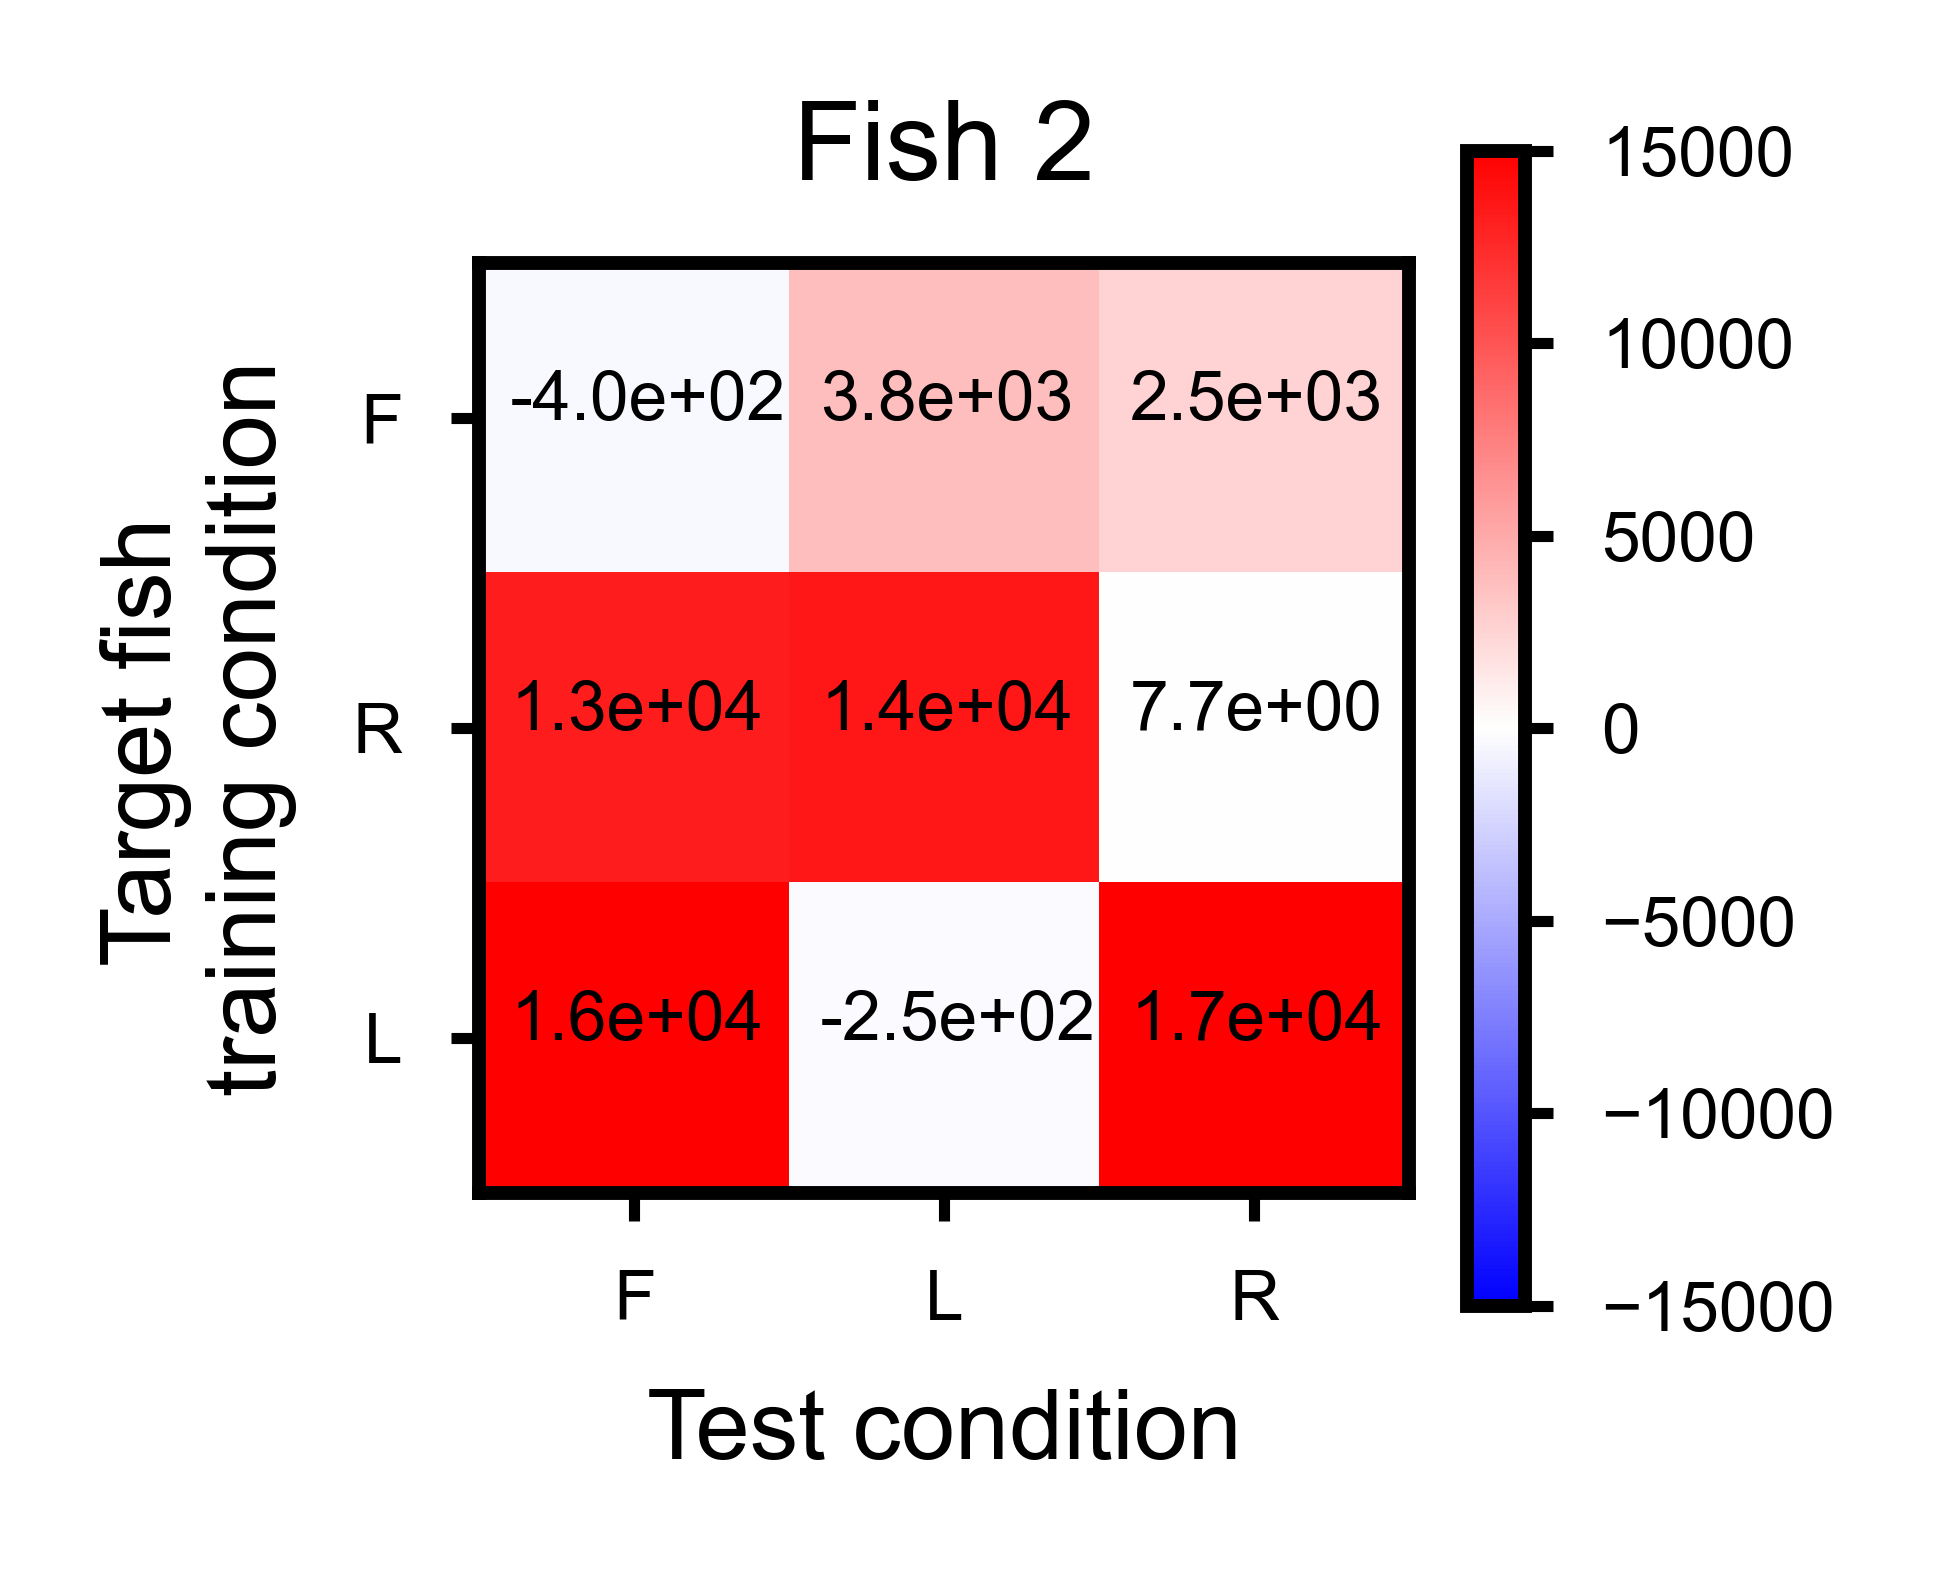

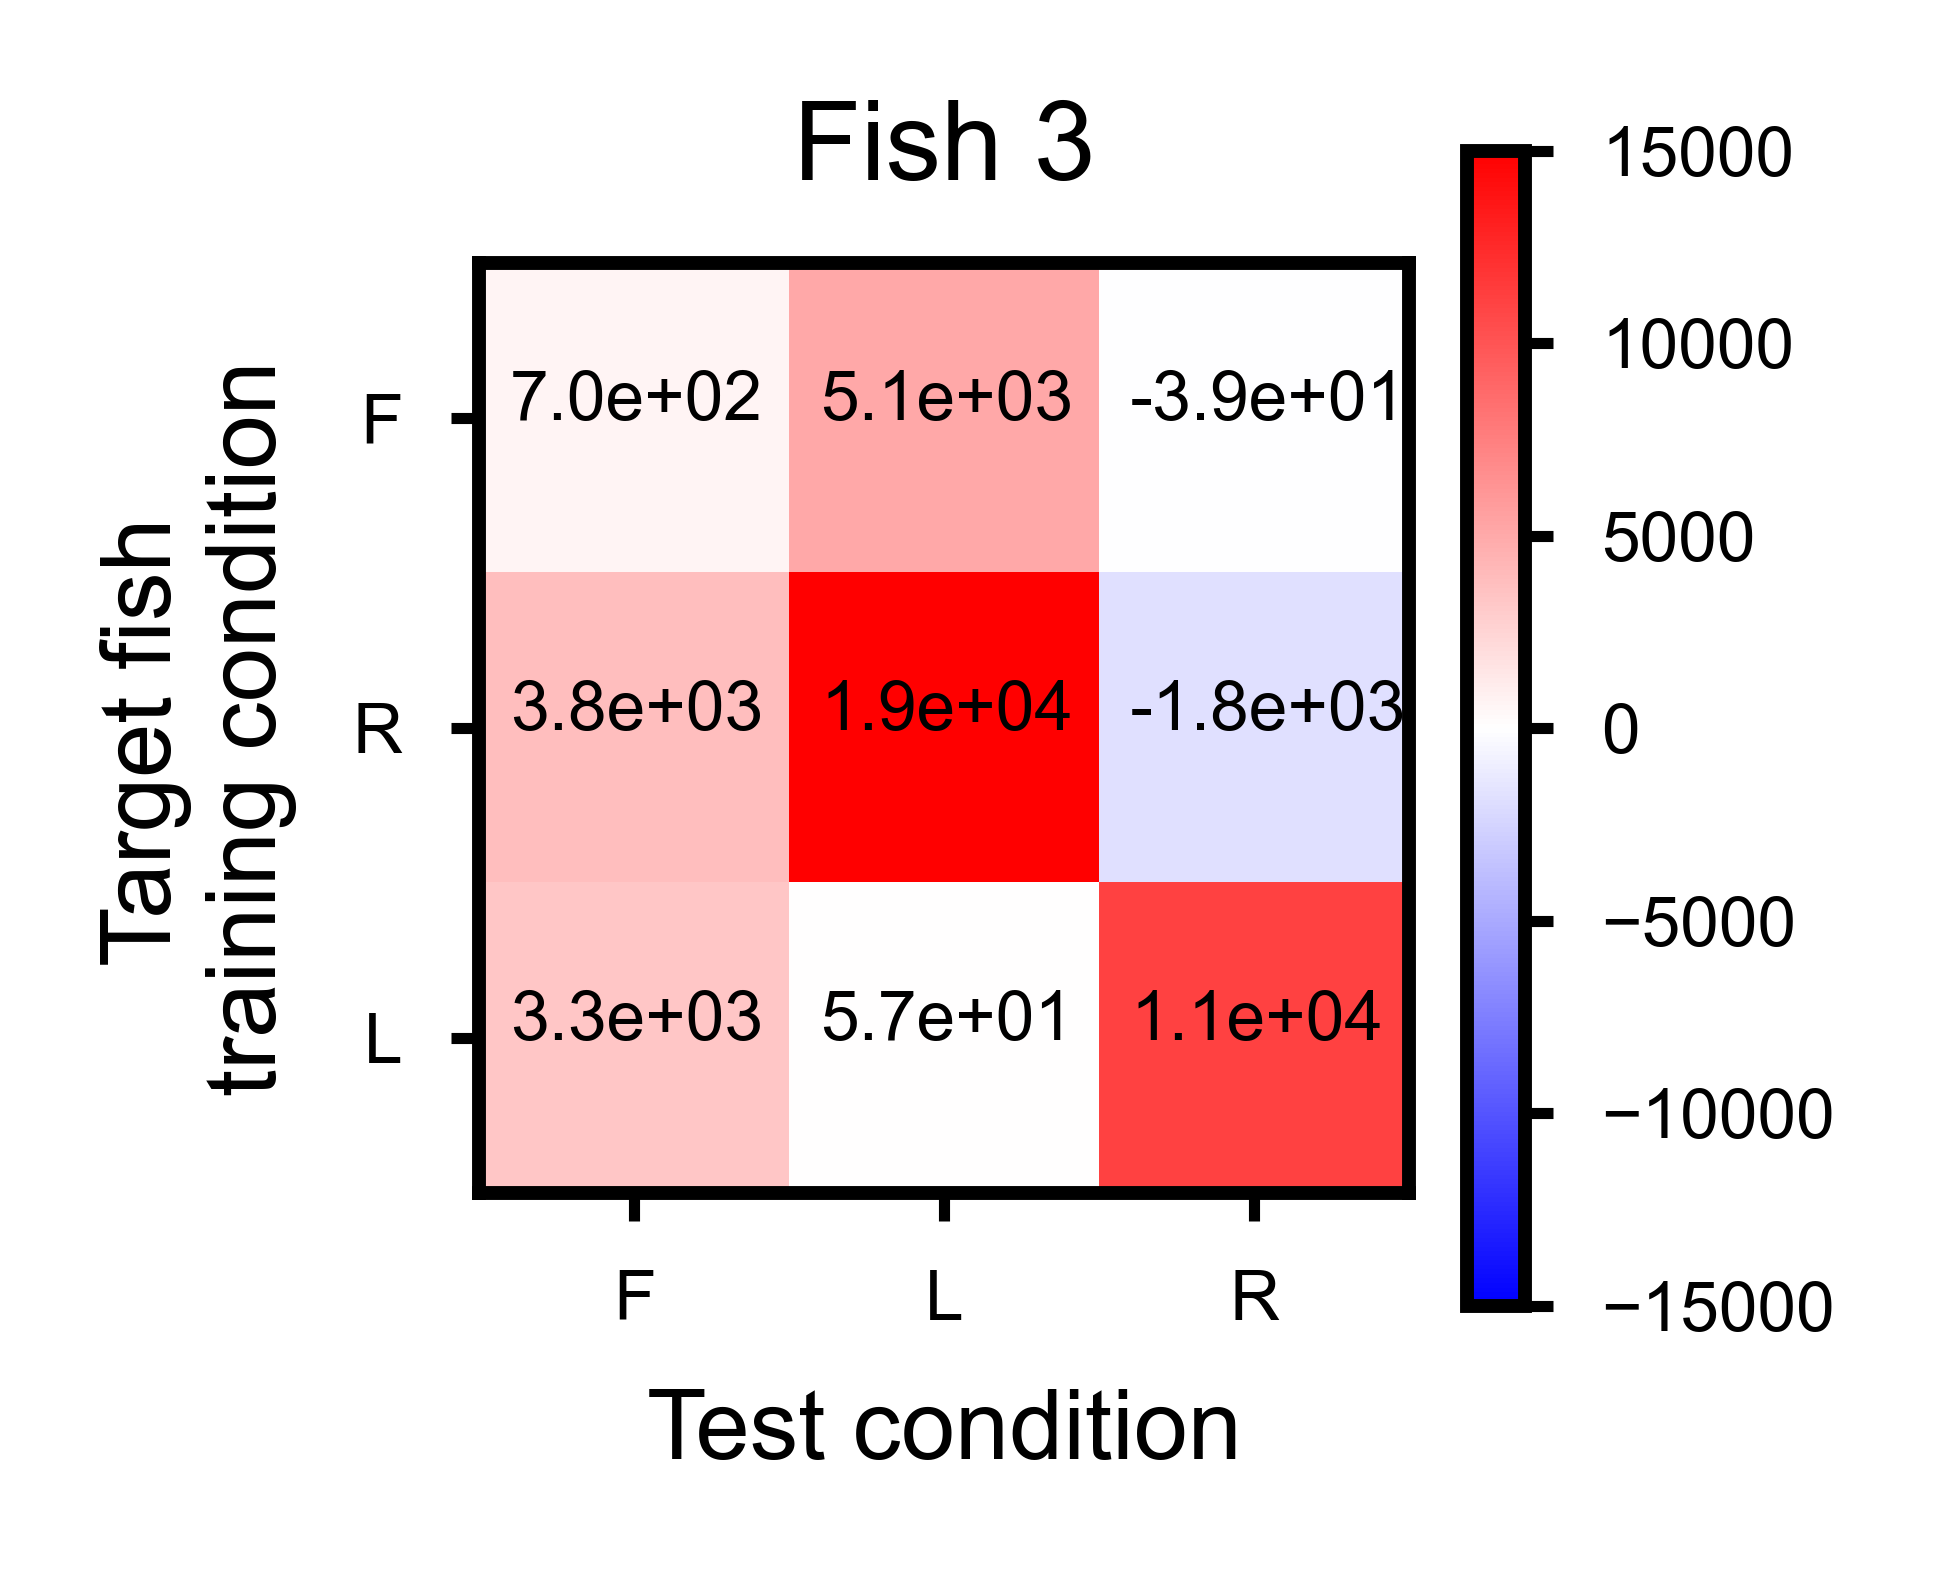

In [35]:
for subj_i, subj in enumerate(test_subjs):
    elbo_improvements = subj_elbos[subj]['multi_cond'] - subj_elbos[subj]['single_cond']  
    fig = plt.figure(figsize=(1.5, 1.5))
    ax = plt.subplot(1,1,1)
    colorized_tbl(tbl=elbo_improvements.to_numpy(), cmap='bwr', vmin=-vl_range, vmax=vl_range, 
                  dim_0_lbls=elbo_improvements.index.to_list(), 
                  dim_1_lbls=elbo_improvements.columns.to_list(), 
                  tbl_fontsize=5, label_fontsize=5,
                  ax=ax)
    ax.set_xlabel('Test condition')
    ax.set_ylabel('Target fish \ntraining condition')
    ax.set_title(f'Fish {subj_i+1}')
    
    save_file = 'elbo_improvements_subj_' + str(subj) + '.svg'
    save_path = Path(save_folder) / save_file
    plt.savefig(save_path, format='svg', dpi=500, bbox_inches="tight", pad_inches=0.05, transparent=True)

## Statistical testing

In [36]:
# Create matrix with all animals
multi_cond_elbos = np.stack([subj_elbos[subj]['multi_cond'].to_numpy() for subj in test_subjs])
single_cond_elbos = np.stack([subj_elbos[subj]['single_cond'].to_numpy() for subj in test_subjs])

# Get values for each type (off-diagonal, diagonal and for all conditions)
# For each, we average across the columns, leaving out the diagonal value, as each column has the same data

### Off-diagonal
multi_cond_vals_offd = np.concatenate([(elbos.sum(axis=0) - np.diag(elbos)) / (elbos.shape[0] - 1) for elbos in multi_cond_elbos])
single_cond_vals_offd = np.concatenate([(elbos.sum(axis=0) - np.diag(elbos)) / (elbos.shape[0] - 1) for elbos in single_cond_elbos])

### Diagonal
multi_cond_vals_d = np.concatenate([np.diag(elbos) for elbos in multi_cond_elbos])
single_cond_vals_d = np.concatenate([np.diag(elbos) for elbos in single_cond_elbos])

### All
multi_cond_vals_full = np.concatenate([np.mean(elbos, axis=0) for elbos in multi_cond_elbos])
single_cond_vals_full = np.concatenate([np.mean(elbos, axis=0) for elbos in single_cond_elbos])

### Wilcoxon Signed-Rank Test

In [37]:
from scipy.stats import wilcoxon

### Off-diagonal
statistic_offd, p_value_offd = wilcoxon(multi_cond_vals_offd, single_cond_vals_offd, alternative='two-sided')
print(f'p value off-diagonal: {p_value_offd:.2e}')

### Diagonal
statistic_d, p_value_d = wilcoxon(multi_cond_vals_d, single_cond_vals_d, alternative='two-sided')
print(f'p value diagonal: {p_value_d:.2e}')

### All
statistic_full, p_value_full = wilcoxon(multi_cond_vals_full, single_cond_vals_full, alternative='two-sided')
print(f'p value full: {p_value_full:.2e}')

p value off-diagonal: 7.81e-03
p value diagonal: 1.95e-02
p value full: 3.91e-03


### Permutation Test

In [17]:
def paired_permutation_test(db_vals, sb_vals, n_permutations=10000, alternative='greater', random_state=None):
    """
    Performs a paired permutation test (sign flipping) between db and sb values.
    
    Args:
        db_vals: np.ndarray, shape (n,) — values under db condition
        sb_vals: np.ndarray, shape (n,) — values under sb condition
        n_permutations: int — number of permutations
        alternative: str — 'greater', 'less', or 'two-sided'
        random_state: int or None — for reproducibility

    Returns:
        p_value: float — permutation p-value
        observed_stat: float — observed mean difference
        null_distribution: np.ndarray — distribution of permuted statistics
    """

    n_permutations = int(n_permutations)
    
    rng = np.random.default_rng(random_state)
    differences = db_vals - sb_vals
    observed_stat = np.mean(differences)

    # Create a (n_permutations, n_samples) array of random ±1
    signs = rng.choice([-1, 1], size=(n_permutations, len(differences)))
    permuted_differences = signs * differences
    permuted_stats = permuted_differences.mean(axis=1)

    # Compute p-value based on alternative
    if alternative == 'greater':
        p_value = np.mean(permuted_stats >= observed_stat)
    elif alternative == 'less':
        p_value = np.mean(permuted_stats <= observed_stat)
    elif alternative == 'two-sided':
        p_value = np.mean(np.abs(permuted_stats) >= np.abs(observed_stat))
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    return p_value

In [18]:
n_permutations = 1e7

### Off-diagonal
p_value_offd = paired_permutation_test(multi_cond_vals_offd, single_cond_vals_offd, n_permutations=n_permutations, alternative='greater')
print(f'p value off-diagonal: {p_value_offd:.2e}')

### Diagonal
p_value_d = paired_permutation_test(multi_cond_vals_d, single_cond_vals_d, n_permutations=n_permutations, alternative='greater')
print(f'p value diagonal: {p_value_d:.2e}')

### All
p_value_full = paired_permutation_test(multi_cond_vals_full, single_cond_vals_full, n_permutations=n_permutations, alternative='greater')
print(f'p value full: {p_value_full:.2e}')

p value off-diagonal: 3.88e-03
p value diagonal: 7.81e-03
p value full: 1.93e-03
